In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
import tensorflow as tf
from tensorflow import keras

In [4]:
from tensorflow.keras.preprocessing.image import load_img

In [ ]:
path = "../data/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
full_name = f"{path}/{name}"
img = load_img(full_name,target_size=(299,299))

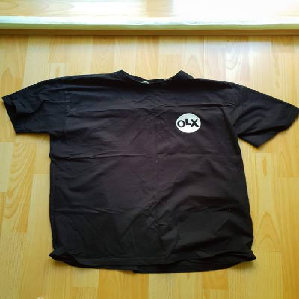

In [ ]:
img

In [ ]:
print(img)

<PIL.Image.Image image mode=RGB size=299x299 at 0x7A5856C7C230>


In [ ]:
#converting image to array
x = np.array(img)

In [ ]:
# 3 channels with RGB
x.shape

(299, 299, 3)

## Pre-trained convolutional neural networks

- Imagenet Dataset: https://www.image-net.org/

- Pre-trained models: https://keras.io/api/applications/

In [5]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [ ]:
model = Xception(weights="imagenet",input_shape=(299,299,3))

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X = np.array([x])

In [ ]:
X.shape

(1, 299, 299, 3)

In [ ]:
X = preprocess_input(X)

In [ ]:
X[0]

array([[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.41960788,  0.35686278, -0.20784312],
        ...,
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.99215686,  0.9372549 ]],

       [[ 0.47450984,  0.4039216 , -0.12156862],
        [ 0.4666667 ,  0.39607847, -0.12941176],
        [ 0.45882356,  0.38823533, -0.15294117],
        ...,
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.92941177]],

       [[ 0.56078434,  0.48235297, -0.00392157],
        [ 0.5686275 ,  0.4901961 ,  0.00392163],
        [ 0.5686275 ,  0.49803925, -0.01176471],
        ...,
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863]],

       ...,

       [[ 0.2941177 ,  0.18431377, -0.40392154],
        [ 0

In [ ]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step


In [ ]:
pred.shape

(1, 1000)

In [ ]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n03595614', 'jersey', np.float32(0.68196356)),
  ('n02916936', 'bulletproof_vest', np.float32(0.038139977)),
  ('n04370456', 'sweatshirt', np.float32(0.034324735)),
  ('n03710637', 'maillot', np.float32(0.011354207)),
  ('n04525038', 'velvet', np.float32(0.0018453562))]]

## Transfer Learning

- Keep the convolutional layers of imagenet because its more generic

- train on the dataset we have this creates new denselayers

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_ds= train_gen.flow_from_directory("../data/train",target_size=(150,150),batch_size=32)

Found 3068 images belonging to 10 classes.


In [ ]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [ ]:
X,y = next(train_ds)

In [ ]:
X.shape

(32, 150, 150, 3)

In [ ]:
y[:5]

array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
# for validation

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_ds= val_gen.flow_from_directory("../data/validation",target_size=  (150,150),batch_size=32,shuffle=False)

Found 341 images belonging to 10 classes.


In [ ]:
# training a base model

base_model = Xception(weights='imagenet',include_top=False,input_shape=(150,150,3))

base_model.trainable = False

inputs = keras.Input(shape=(150,150,3))

base = base_model(inputs,training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs,outputs)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# to train model, we need optimiser, we need to change the weights which lead to better solution

learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


96/96 ━━━━━━━━━━━━━━━━━━━━ 52s 363ms/step - accuracy: 0.5767 - loss: 1.5386 - val_accuracy: 0.7771 - val_loss: 0.9061
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8182 - loss: 0.6178 - val_accuracy: 0.7595 - val_loss: 0.8761
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8895 - loss: 0.3300 - val_accuracy: 0.7889 - val_loss: 0.8741
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.9210 - loss: 0.2026 - val_accuracy: 0.8006 - val_loss: 0.8275
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9548 - loss: 0.1206 - val_accuracy: 0.8182 - val_loss: 0.8337
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9677 - loss: 0.0926 - val_accuracy: 0.7889 - val_loss: 1.1398
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9731 - loss: 0.0856 - val_accuracy: 0.8152 - val_loss: 1.0153
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9726 - loss: 0.0773 - val_accuracy: 0.8270 - val_loss: 

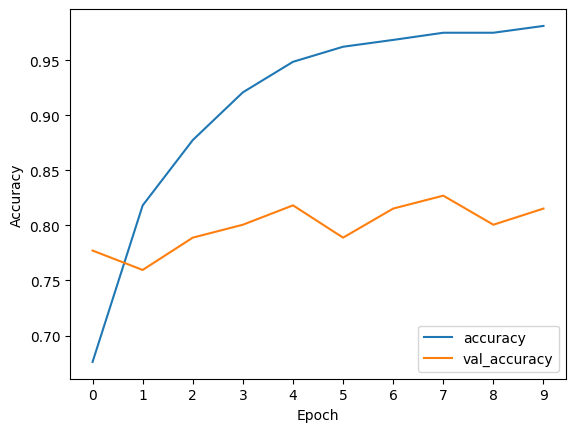

In [ ]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(10))
plt.legend(loc='lower right')
plt.show()

# Adjusting the learning rate

In [ ]:
def make_model(learning_rate = 0.01):
    # training a base model

    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3)
                         )
    ######################################################

    base_model.trainable = False
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs,training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs,outputs)
    ##############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])
    return model

In [ ]:
scores = {}
for lr in [0.0001,0.001,0.01,0.1]:
    print(f"learning rate : {lr}")

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds,epochs=10,validation_data=val_ds)
    scores[lr]=history.history

    print()
    print()

learning rate : 0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 224ms/step - accuracy: 0.2298 - loss: 2.2041 - val_accuracy: 0.4604 - val_loss: 1.6029
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.5335 - loss: 1.4565 - val_accuracy: 0.5953 - val_loss: 1.2588
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.6275 - loss: 1.1890 - val_accuracy: 0.6569 - val_loss: 1.0750
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.6864 - loss: 1.0207 - val_accuracy: 0.6950 - val_loss: 0.9687
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.7067 - loss: 0.9401 - val_accuracy: 0.7155 - val_loss: 0.8912
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.7380 - loss: 0.8457 - val_accuracy: 0.7361 - val_loss: 0.8347
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7525 - loss: 0.7989 - val_accuracy: 0.7419 - val_loss: 0.7918
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.7599 - loss: 0.7526 -

In [ ]:
lr_scores = scores

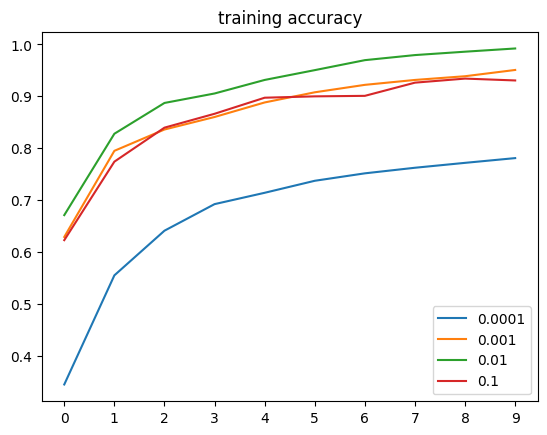

In [ ]:

for lr, hist in lr_scores.items():
    plt.plot(hist['accuracy'],label=lr)
    #plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('training accuracy')
plt.legend()

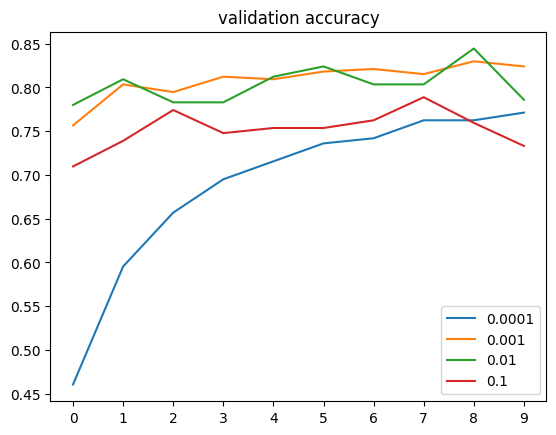

In [ ]:
for lr, hist in lr_scores.items():
    #plt.plot(hist['accuracy'],label=lr)
    plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('validation accuracy')
plt.legend()

In [ ]:
learning_rate=0.001

## Checkpointing

- Saving the best model only
- Traiing a model with callbacks

In [ ]:
model.save_weights('model_v1.weights.h5')

In [ ]:
epoch = 12
val_accuracy=0.824
f"xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5"

'xception_v1_12_0.824.h5'

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint('xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
                                             save_best_only=True,
                                             monitor='val_accuracy',
                                             mode='max'
                                            )

In [ ]:
learning_rate = 0.01

model = make_model(learning_rate=learning_rate)

history = model.fit(train_ds,epochs=10,
                    validation_data=val_ds,
                    callbacks=[checkpoint])



Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5422 - loss: 1.8584

96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 190ms/step - accuracy: 0.5435 - loss: 1.8525 - val_accuracy: 0.8094 - val_loss: 0.7100
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8534 - loss: 0.4434 - val_accuracy: 0.7830 - val_loss: 0.8095
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.8673 - loss: 0.4074 - val_accuracy: 0.7537 - val_loss: 1.1090
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9051 - loss: 0.2877 - val_accuracy: 0.7947 - val_loss: 0.8047
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9475 - loss: 0.1482 - val_accuracy: 0.7977 - val_loss: 0.7989
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9686 - loss: 0.0939

96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9686 - loss: 0.0940 - val_accuracy: 0.8152 - val_loss: 0.8299
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9777 - loss: 0.0713 - val_accuracy: 0.8094 - val_loss: 0.8018
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9920 - loss: 0.0385

96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9920 - loss: 0.0385 - val_accuracy: 0.8182 - val_loss: 0.8266
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9986 - loss: 0.0246

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9986 - loss: 0.0247 - val_accuracy: 0.8270 - val_loss: 0.8794
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9968 - loss: 0.0246 - val_accuracy: 0.8152 - val_loss: 0.8696


## Adding more layers
- Adding one inner dense layer
- Experimenting with different sizes of inner layer

In [ ]:
def make_model(learning_rate = 0.01,size_inner=100):
    # training a base model

    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3)
                         )
    base_model.trainable = False
    ######################################################
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs,training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner,activation='relu')(vectors)
    outputs = keras.layers.Dense(10)(inner)

    model = keras.Model(inputs,outputs)
    ##############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])
    return model

In [ ]:
learning_rate = 0.01

scores = {}

for size in [10,100,1000]:
    print(f"for size : {size}")

    model = make_model(learning_rate=learning_rate,size_inner=size)
    history = model.fit(train_ds,epochs=10,validation_data=val_ds)
    scores[size]=history.history

    print()
    print()

for size : 10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 198ms/step - accuracy: 0.2754 - loss: 2.1038 - val_accuracy: 0.4751 - val_loss: 1.4710
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.4864 - loss: 1.4114 - val_accuracy: 0.5015 - val_loss: 1.3756
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.5112 - loss: 1.2986 - val_accuracy: 0.4927 - val_loss: 1.3528
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.5336 - loss: 1.2124 - val_accuracy: 0.5308 - val_loss: 1.2960
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.5676 - loss: 1.1068 - val_accuracy: 0.5161 - val_loss: 1.3935
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.5773 - loss: 1.0983 - val_accuracy: 0.5015 - val_loss: 1.3854
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.5979 - loss: 1.0482 - val_accuracy: 0.5572 - val_loss: 1.3001
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6274 - loss: 0.9834 - val_accu

In [ ]:
scores

{10: {'accuracy': [0.3552803099155426,
   0.48598435521125793,
   0.5228161811828613,
   0.5469360947608948,
   0.571056067943573,
   0.5798565745353699,
   0.5932203531265259,
   0.6329856514930725,
   0.6219035387039185,
   0.6525423526763916],
  'loss': [1.8574618101119995,
   1.3964799642562866,
   1.2736955881118774,
   1.1819145679473877,
   1.112178921699524,
   1.093907117843628,
   1.0609159469604492,
   0.9774825572967529,
   0.9581089615821838,
   0.9125133156776428],
  'val_accuracy': [0.47507330775260925,
   0.5014662742614746,
   0.49266862869262695,
   0.5307917594909668,
   0.5161290168762207,
   0.5014662742614746,
   0.5571847558021545,
   0.5659824013710022,
   0.5425220131874084,
   0.5601173043251038],
  'val_loss': [1.4710139036178589,
   1.3756383657455444,
   1.3527849912643433,
   1.2959580421447754,
   1.3935301303863525,
   1.3854349851608276,
   1.3001407384872437,
   1.2598012685775757,
   1.3120671510696411,
   1.3096861839294434]},
 100: {'accuracy': [0.6

In [ ]:
inner_layer_size_scores = scores

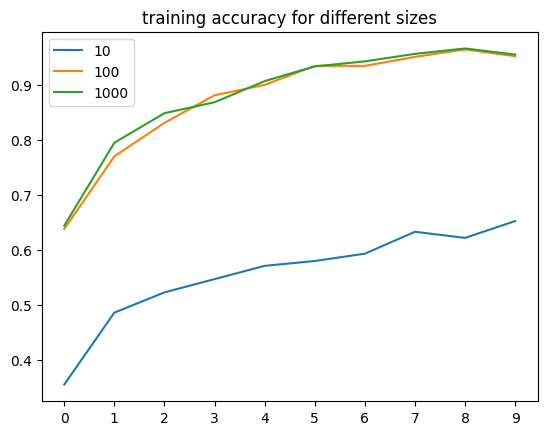

In [ ]:

for size, hist in inner_layer_size_scores.items():
    plt.plot(hist['accuracy'],label=size)
    #plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('training accuracy for different sizes')
plt.legend()

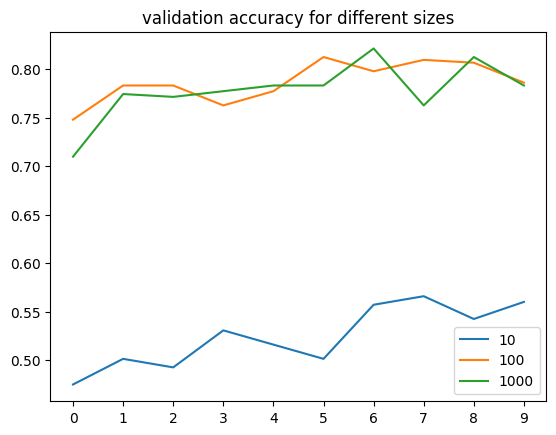

In [ ]:

for size, hist in inner_layer_size_scores.items():
    #plt.plot(hist['accuracy'],label=size)
    plt.plot(hist['val_accuracy'],label=size)

plt.xticks(np.arange(10))
plt.title('validation accuracy for different sizes')
plt.legend()

## Regularizing by dropout

- Regularizing by freezing a part of the network
- Adding dropout to our model
- Experimenting with different values

In [ ]:
def make_model(learning_rate = 0.01,size_inner=100,droprate=0.5):
    # training a base model

    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(150,150,3)
                         )
    base_model.trainable = False
    ######################################################
    inputs = keras.Input(shape=(150,150,3))
    base = base_model(inputs,training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner,activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs,outputs)
    ##############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])
    return model

In [ ]:
learning_rate = 0.01
size = 100

scores = {}

for droprate in [0.0,0.2,0.5,0.8]:
    print(f"for droprate : {droprate}")

    model = make_model(learning_rate=learning_rate,size_inner=size,droprate=droprate)
    history = model.fit(train_ds,epochs=30,validation_data=val_ds)
    scores[droprate]=history.history

    print()
    print()

for droprate : 0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 192ms/step - accuracy: 0.5358 - loss: 1.7982 - val_accuracy: 0.7097 - val_loss: 0.8080
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.7830 - loss: 0.6166 - val_accuracy: 0.7859 - val_loss: 0.6932
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.8445 - loss: 0.4466 - val_accuracy: 0.7361 - val_loss: 0.8987
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.8875 - loss: 0.3043 - val_accuracy: 0.7801 - val_loss: 0.7602
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9030 - loss: 0.2845 - val_accuracy: 0.8006 - val_loss: 0.7520
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9485 - loss: 0.1592 - val_accuracy: 0.8035 - val_loss: 0.8647
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9513 - loss: 0.1251 - val_accuracy: 0.7918 - val_loss: 0.8393
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9702 - loss: 0.0841 - val

In [ ]:
droprate_scores= scores

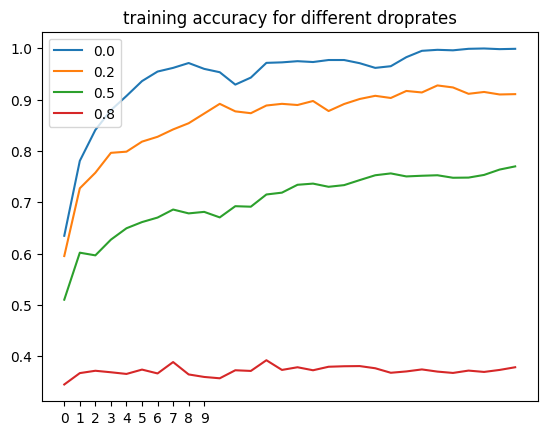

In [ ]:

for droprate, hist in droprate_scores.items():
    plt.plot(hist['accuracy'],label=droprate)
    #plt.plot(hist['val_accuracy'],label=lr)

plt.xticks(np.arange(10))
plt.title('training accuracy for different droprates')
plt.legend()

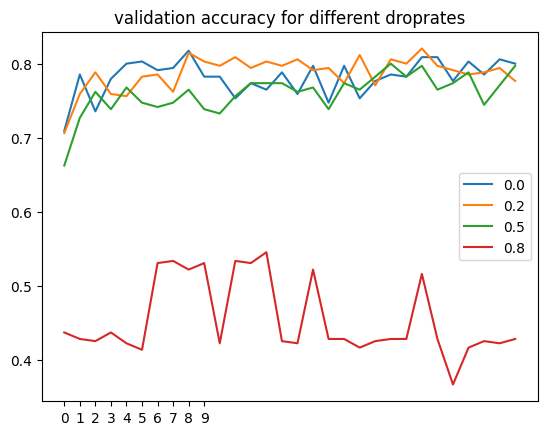

In [ ]:

for droprate, hist in droprate_scores.items():
    #plt.plot(hist['accuracy'],label=size)
    plt.plot(hist['val_accuracy'],label=droprate)

plt.xticks(np.arange(10))
plt.title('validation accuracy for different droprates')
plt.legend()

In [ ]:
droprate=0.2

# Data Augumentation
Generate images from existing images
- flip the image horizontally
- flip the image vertivcally

In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=10.0,
    height_shift_range=10.0,
    shear_range=10.0,
    zoom_range=0.1,
    horizontal_flip=False,
    vertical_flip=True
    )

train_ds= train_gen.flow_from_directory("../data/train",
                                        target_size=(150,150),
                                        batch_size=32
                                        )

# for validation

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input)

val_ds= val_gen.flow_from_directory("../data/validation",
                                    target_size=  (150,150),
                                    batch_size=32,
                                    shuffle=False)



Found 3068 images belonging to 10 classes.


After training above we didn't see significant improvement in validation accuracy so

In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10.0,
    zoom_range=0.1,
    vertical_flip=True
    )

train_ds= train_gen.flow_from_directory("../data/train",
                                        target_size=(150,150),
                                        batch_size=32
                                        )

# for validation

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input)

val_ds= val_gen.flow_from_directory("../data/validation",
                                    target_size=  (150,150),
                                    batch_size=32,
                                    shuffle=False)



Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [ ]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(learning_rate=learning_rate,
                   size_inner=size,
                   droprate=droprate)

history = model.fit(train_ds,epochs=50,validation_data=val_ds)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 352ms/step - accuracy: 0.4761 - loss: 1.6143 - val_accuracy: 0.7361 - val_loss: 0.7701
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 223ms/step - accuracy: 0.6954 - loss: 0.9103 - val_accuracy: 0.7742 - val_loss: 0.7010
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 232ms/step - accuracy: 0.7328 - loss: 0.8049 - val_accuracy: 0.7771 - val_loss: 0.6727
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - accuracy: 0.7549 - loss: 0.7074 - val_accuracy: 0.7977 - val_loss: 0.6340
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 228ms/step - accuracy: 0.7852 - loss: 0.6419 - val_accuracy: 0.7859 - val_loss: 0.6249
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 223ms/step - accuracy: 0.8052 - loss: 0.5974 - val_accuracy: 0.7742 - val_loss: 0.6405
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 235ms/step - accuracy: 0.7877 - loss: 0.6090 - val_accuracy: 0.7977 - val_loss: 0.6064
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 231ms/step - accuracy: 0.8078 - loss: 0.5455 - val_accu

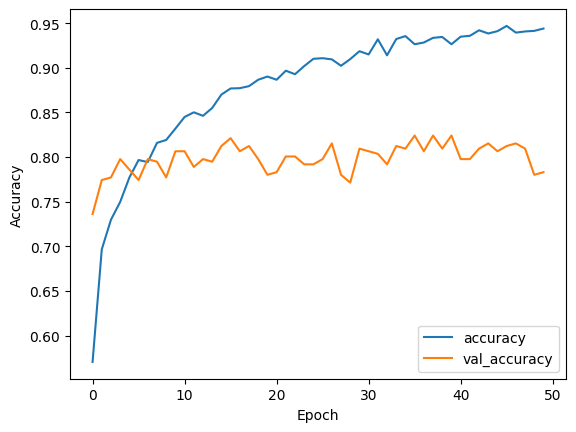

In [ ]:
hist = history.history
plt.plot(hist['accuracy'],label='accuracy')
plt.plot(hist['val_accuracy'],label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

## Training Larger model

In [7]:
def make_model(input_size = 150,learning_rate = 0.01,
               size_inner=100,droprate=0.5):
    # training a base model

    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(input_size,input_size,3)
                         )
    base_model.trainable = False
    ######################################################
    inputs = keras.Input(shape=(input_size,input_size,3))
    base = base_model(inputs,training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner,activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs,outputs)
    ##############################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])
    return model

In [8]:
input_size = 299

In [11]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10.0,
    zoom_range=0.1,
    horizontal_flip=True
    )

train_ds= train_gen.flow_from_directory("../data/train",
                                        target_size=(input_size,input_size),
                                        batch_size=32
                                        )

# for validation

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input)

val_ds= val_gen.flow_from_directory("../data/validation",
                                    target_size=  (input_size,input_size),
                                    batch_size=32,
                                    shuffle=False)



Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [12]:
checkpoint = keras.callbacks.ModelCheckpoint('xception_v4_{epoch:02d}_{val_accuracy:.3f}.h5',
                                             save_best_only=True,
                                             monitor='val_accuracy',
                                             mode='max'
                                            )

In [13]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(input_size = input_size,
                   learning_rate=learning_rate,
                   size_inner=size,
                   droprate=droprate)

history = model.fit(train_ds,epochs=50,validation_data=val_ds,callbacks=[checkpoint])

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5929 - loss: 1.2430

96/96 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.5941 - loss: 1.2390 - val_accuracy: 0.8651 - val_loss: 0.4410
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 735ms/step - accuracy: 0.8409 - loss: 0.4513 - val_accuracy: 0.8534 - val_loss: 0.4187
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.8684 - loss: 0.3746

96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 756ms/step - accuracy: 0.8683 - loss: 0.3747 - val_accuracy: 0.8739 - val_loss: 0.3851
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 744ms/step - accuracy: 0.8751 - loss: 0.3369 - val_accuracy: 0.8680 - val_loss: 0.3951
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 744ms/step - accuracy: 0.8985 - loss: 0.2926 - val_accuracy: 0.8622 - val_loss: 0.3638
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.9122 - loss: 0.2556

96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 759ms/step - accuracy: 0.9121 - loss: 0.2559 - val_accuracy: 0.8827 - val_loss: 0.3497
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 747ms/step - accuracy: 0.9020 - loss: 0.2685 - val_accuracy: 0.8739 - val_loss: 0.3754
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 745ms/step - accuracy: 0.9206 - loss: 0.2297 - val_accuracy: 0.8592 - val_loss: 0.3552
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 745ms/step - accuracy: 0.9207 - loss: 0.2147 - val_accuracy: 0.8798 - val_loss: 0.3670
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.9356 - loss: 0.1893

96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 752ms/step - accuracy: 0.9356 - loss: 0.1893 - val_accuracy: 0.8856 - val_loss: 0.3640
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 740ms/step - accuracy: 0.9390 - loss: 0.1832 - val_accuracy: 0.8798 - val_loss: 0.3682
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 742ms/step - accuracy: 0.9264 - loss: 0.1853 - val_accuracy: 0.8651 - val_loss: 0.4215
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 761ms/step - accuracy: 0.9417 - loss: 0.1701 - val_accuracy: 0.8651 - val_loss: 0.4262
Epoch 14/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 738ms/step - accuracy: 0.9421 - loss: 0.1591 - val_accuracy: 0.8768 - val_loss: 0.4134
Epoch 15/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 737ms/step - accuracy: 0.9500 - loss: 0.1433 - val_accuracy: 0.8504 - val_loss: 0.4429
Epoch 16/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 744ms/step - accuracy: 0.9542 - loss: 0.1305 - val_accuracy: 0.8739 - val_loss: 0.3799
Epoch 17/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 739ms/step - accuracy: 0.9624 - loss: 0.1134 - val_accuracy

96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 757ms/step - accuracy: 0.9841 - loss: 0.0556 - val_accuracy: 0.8915 - val_loss: 0.4685
Epoch 39/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.9864 - loss: 0.0498

96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 752ms/step - accuracy: 0.9864 - loss: 0.0497 - val_accuracy: 0.8944 - val_loss: 0.5000
Epoch 40/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 754ms/step - accuracy: 0.9805 - loss: 0.0530 - val_accuracy: 0.8915 - val_loss: 0.4587
Epoch 41/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 741ms/step - accuracy: 0.9841 - loss: 0.0533 - val_accuracy: 0.8886 - val_loss: 0.5050
Epoch 42/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 743ms/step - accuracy: 0.9881 - loss: 0.0386 - val_accuracy: 0.8622 - val_loss: 0.5700
Epoch 43/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 744ms/step - accuracy: 0.9853 - loss: 0.0413 - val_accuracy: 0.8827 - val_loss: 0.5230
Epoch 44/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 752ms/step - accuracy: 0.9861 - loss: 0.0479 - val_accuracy: 0.8798 - val_loss: 0.4872
Epoch 45/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 70s 724ms/step - accuracy: 0.9892 - loss: 0.0377 - val_accuracy: 0.8651 - val_loss: 0.5195
Epoch 46/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 69s 719ms/step - accuracy: 0.9826 - loss: 0.0492 - val_accuracy